In [4]:
# notebooks/02_eda.ipynb
# ─────────────────────────────────────────────────────────────────────────────
# EDA — Loan Eligibility Prediction
# Goal: understand every feature's distribution and its relationship
#       to loan approval before writing any modeling code.
# ─────────────────────────────────────────────────────────────────────────────

import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

from data_loader import load_raw_data, clean_dependents, handle_credit_history, encode_target

warnings.filterwarnings('ignore')

# ── Professional plot style ──────────────────────────────────────────────────
# This makes every chart look recruiter-worthy with one line
plt.rcParams.update({
    'figure.facecolor': '#0f1117',   # dark background — stands out on GitHub
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#3a3d4a',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#a0a0a0',
    'ytick.color':      '#a0a0a0',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2d3a',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'sans-serif',
    'font.size':        11,
})

APPROVE_COLOR  = '#00c896'   # green  — approved loans
REJECT_COLOR   = '#ff4d6d'   # red    — rejected loans
NEUTRAL_COLOR  = '#5b7fff'   # blue   — neutral distributions
PALETTE        = [APPROVE_COLOR, REJECT_COLOR]

# ── Load and clean ───────────────────────────────────────────────────────────
df, _ = load_raw_data()
df = clean_dependents(df)
df = handle_credit_history(df)
df = encode_target(df)

print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Approval rate: {df['Loan_Status'].mean():.1%}")

Dataset: 614 rows, 13 columns
Approval rate: 68.7%


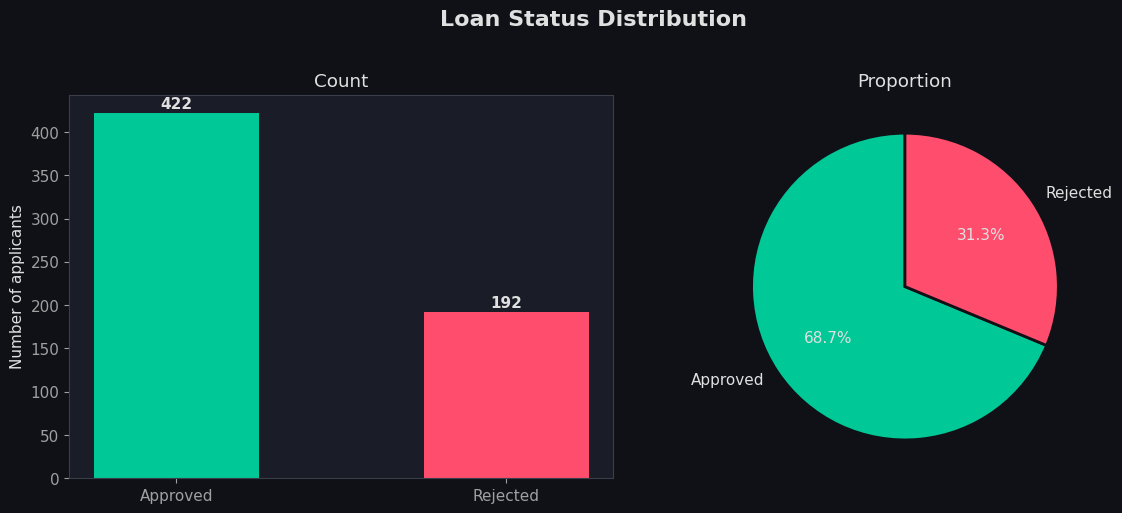

Baseline accuracy (approve everyone): 0.6872964169381107


In [5]:
# ── TARGET DISTRIBUTION ──────────────────────────────────────────────────────
# First chart: always show your target variable.
# WHY: sets the baseline for every subsequent chart.
# A reviewer seeing your EDA should immediately know the class distribution.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Loan Status Distribution', fontsize=16, fontweight='bold', y=1.02)

counts = df['Loan_Status'].value_counts()
labels = ['Approved', 'Rejected']

# Left: bar chart with exact counts
bars = axes[0].bar(labels, counts.values, color=PALETTE, width=0.5, edgecolor='none')
axes[0].set_title('Count')
axes[0].set_ylabel('Number of applicants')
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(count), ha='center', fontweight='bold')

# Right: pie chart with percentages
axes[1].pie(counts.values, labels=labels, colors=PALETTE, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': '#0f1117', 'linewidth': 2})
axes[1].set_title('Proportion')

plt.tight_layout()
plt.savefig('../data/processed/eda_01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── BUSINESS INSIGHT ─────────────────────────────────────────────────────────
# This 68.7/31.3 split means our baseline (approve everyone) accuracy = 68.7%.
# Any model scoring below this is worse than a trivial rule.
# We need F1-score and ROC-AUC to measure real performance.
print("Baseline accuracy (approve everyone):", counts.max() / counts.sum())

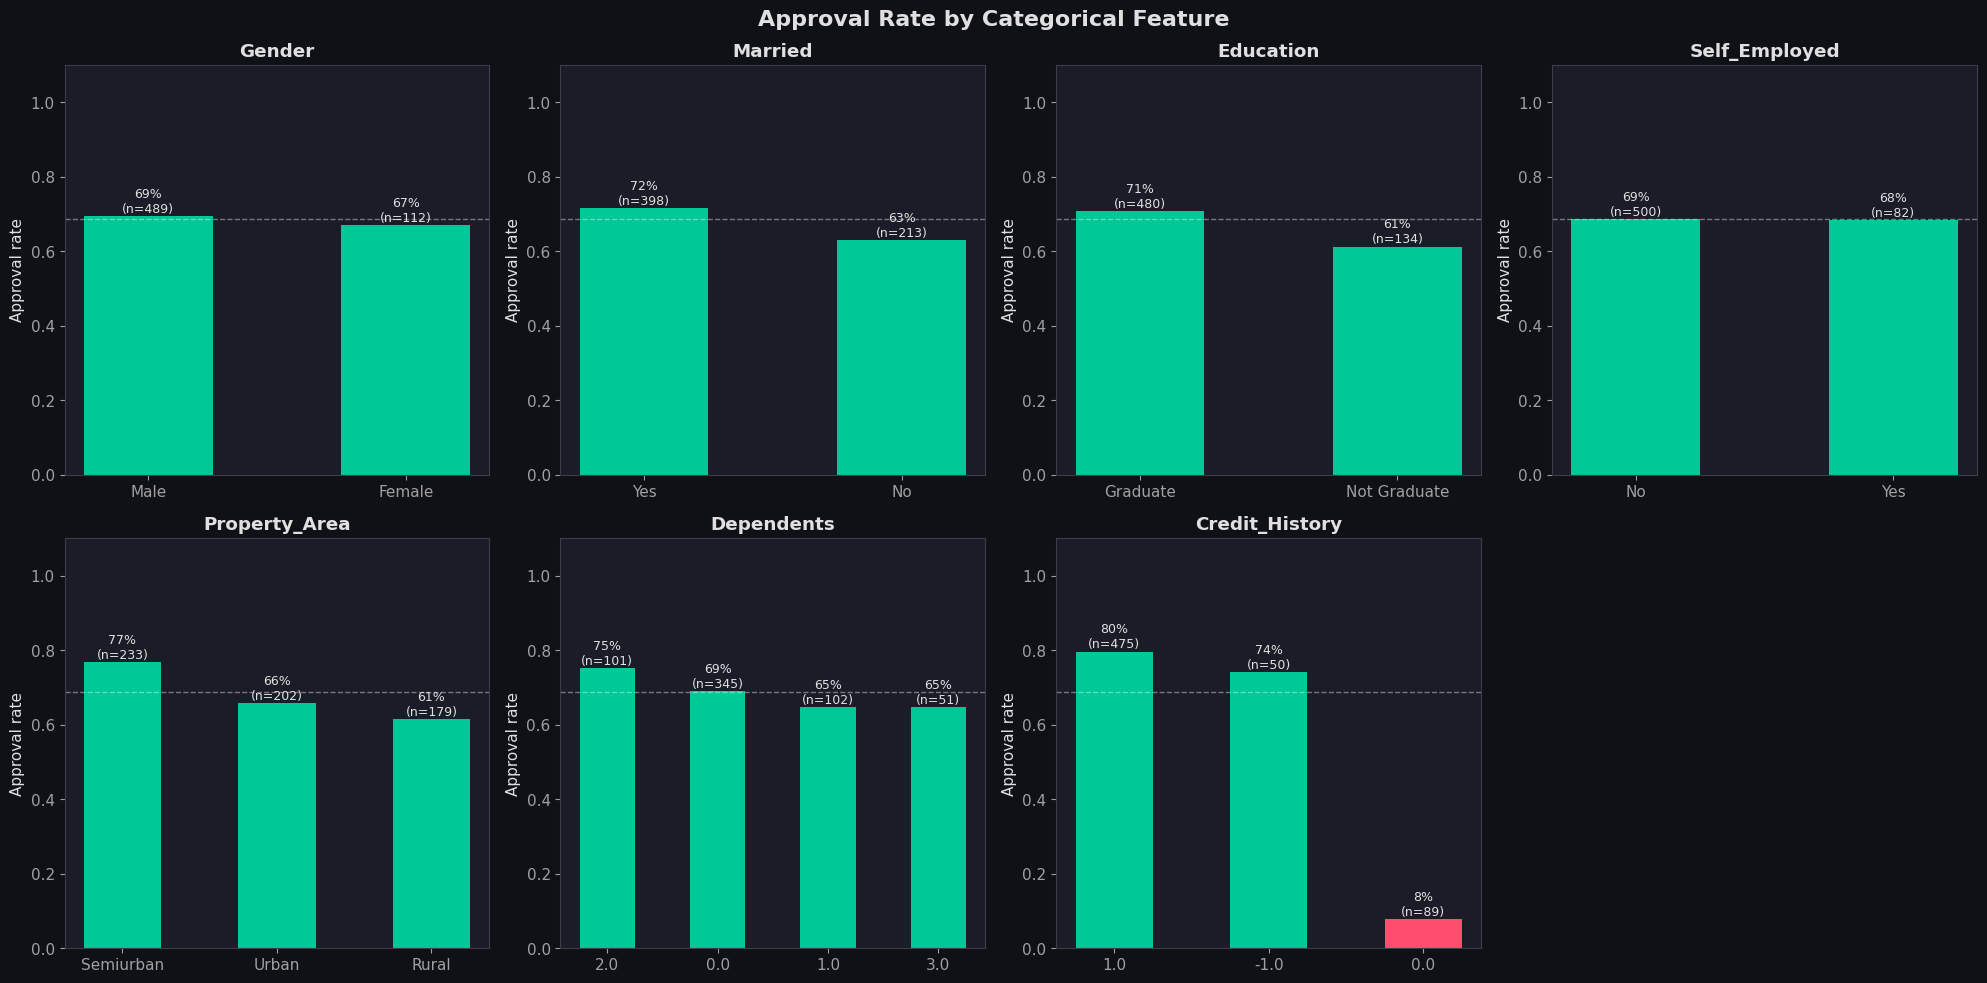

In [6]:
# ── CATEGORICAL FEATURES vs APPROVAL RATE ────────────────────────────────────
# For each categorical feature, show the approval rate per category.
# WHY: this directly answers "does this feature predict approval?"
# A flat approval rate = not predictive. Variation = predictive signal.

categorical_cols = ['Gender', 'Married', 'Education', 'Self_Employed',
                    'Property_Area', 'Dependents', 'Credit_History']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Approval Rate by Categorical Feature', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Calculate approval rate per category
    approval_by_cat = df.groupby(col)['Loan_Status'].agg(['mean', 'count']).reset_index()
    approval_by_cat.columns = [col, 'approval_rate', 'count']
    approval_by_cat = approval_by_cat.sort_values('approval_rate', ascending=False)
    
    # Bar chart colored by approval rate (green=high, red=low)
    colors = [APPROVE_COLOR if r > 0.5 else REJECT_COLOR 
              for r in approval_by_cat['approval_rate']]
    bars = axes[i].bar(approval_by_cat[col].astype(str),
                       approval_by_cat['approval_rate'],
                       color=colors, edgecolor='none', width=0.5)
    
    # Add percentage labels on bars
    for bar, rate, count in zip(bars, approval_by_cat['approval_rate'],
                                 approval_by_cat['count']):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     f'{rate:.0%}\n(n={count})', ha='center', fontsize=9)
    
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Approval rate')
    axes[i].set_ylim(0, 1.1)
    axes[i].axhline(y=0.687, color='white', linestyle='--', alpha=0.4, linewidth=1)
    # ^ dashed line = dataset average — easy to see which categories beat baseline

axes[-1].set_visible(False)   # hide empty 8th subplot

plt.tight_layout()
plt.savefig('../data/processed/eda_02_categorical_approval.png', dpi=150, bbox_inches='tight')
plt.show()

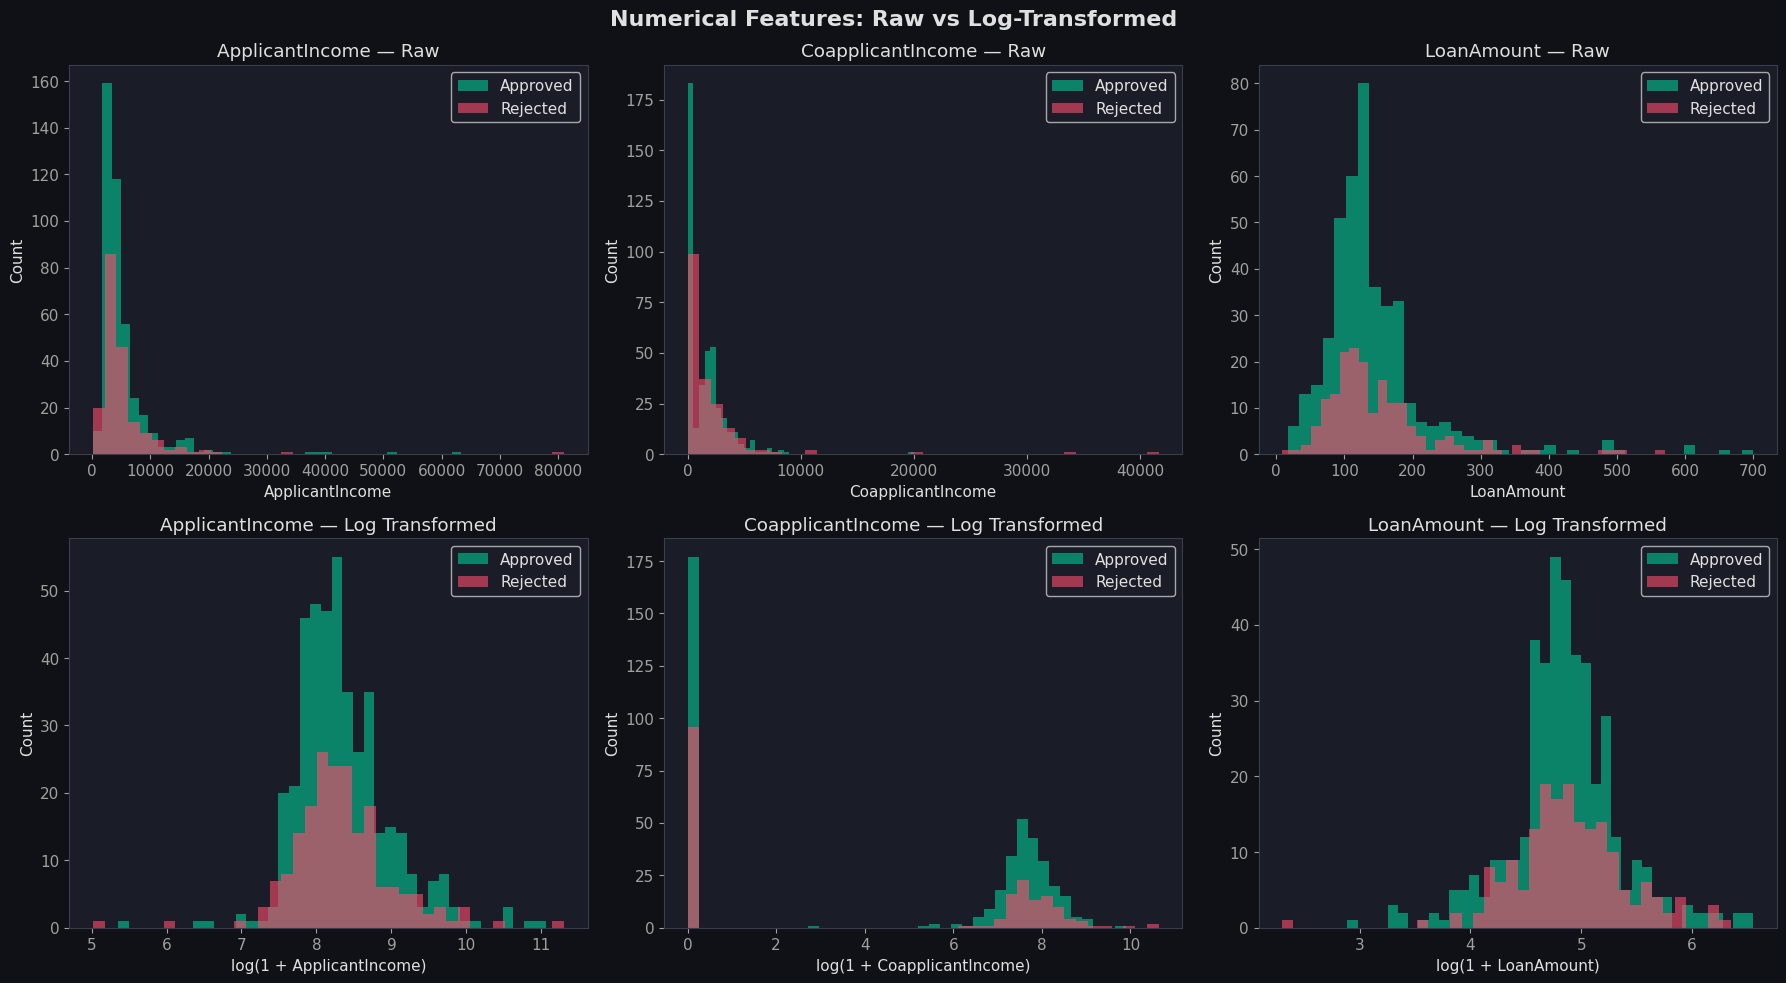

In [7]:
# ── NUMERICAL DISTRIBUTIONS: RAW vs LOG-TRANSFORMED ─────────────────────────
# WHY show both? To justify our preprocessing decision visually.
# A recruiter or interviewer can *see* why log transform is necessary.

numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Numerical Features: Raw vs Log-Transformed', fontsize=16, fontweight='bold')

for i, col in enumerate(numerical_cols):
    # Top row: raw distribution split by approval
    for status, color, label in [(1, APPROVE_COLOR, 'Approved'), 
                                  (0, REJECT_COLOR, 'Rejected')]:
        subset = df[df['Loan_Status'] == status][col].dropna()
        axes[0, i].hist(subset, bins=40, alpha=0.6, color=color, 
                        label=label, edgecolor='none')
    axes[0, i].set_title(f'{col} — Raw')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Count')
    axes[0, i].legend()
    
    # Bottom row: log-transformed distribution
    for status, color, label in [(1, APPROVE_COLOR, 'Approved'), 
                                  (0, REJECT_COLOR, 'Rejected')]:
        subset = np.log1p(df[df['Loan_Status'] == status][col].dropna())
        axes[1, i].hist(subset, bins=40, alpha=0.6, color=color, 
                        label=label, edgecolor='none')
    axes[1, i].set_title(f'{col} — Log Transformed')
    axes[1, i].set_xlabel(f'log(1 + {col})')
    axes[1, i].set_ylabel('Count')
    axes[1, i].legend()

plt.tight_layout()
plt.savefig('../data/processed/eda_03_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

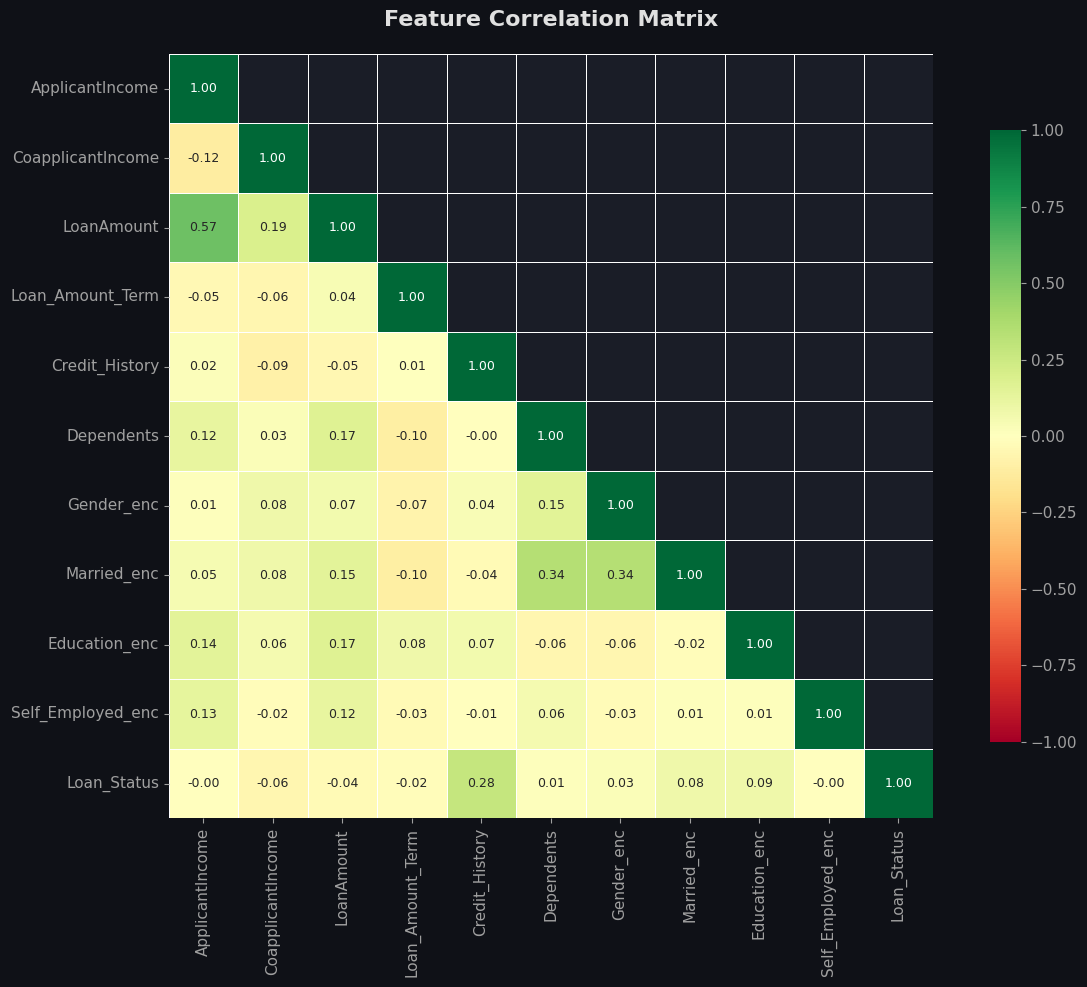


Feature correlations with Loan_Status:
Credit_History       0.280
Education_enc        0.086
Married_enc          0.084
CoapplicantIncome   -0.059
LoanAmount          -0.037
Gender_enc           0.025
Loan_Amount_Term    -0.021
Dependents           0.010
ApplicantIncome     -0.005
Self_Employed_enc   -0.004
Name: Loan_Status, dtype: float64


In [9]:
# ── CORRELATION HEATMAP ──────────────────────────────────────────────────────
# WHY: identifies multicollinear features (potential redundancy)
# and shows which features correlate most strongly with the target.
# Note: Pearson correlation only captures LINEAR relationships.
# A low correlation doesn't mean a feature is useless — it means
# the relationship might be non-linear (which tree models can capture).

# Prepare numeric-only dataframe for correlation
df_numeric = df.copy()
df_numeric['Dependents'] = df_numeric['Dependents'].fillna(df_numeric['Dependents'].median())

# Encode binary categoricals for correlation
df_numeric['Gender_enc']       = (df_numeric['Gender'] == 'Male').astype(float)
df_numeric['Married_enc']      = (df_numeric['Married'] == 'Yes').astype(float)
df_numeric['Education_enc']    = (df_numeric['Education'] == 'Graduate').astype(float)
df_numeric['Self_Employed_enc'] = (df_numeric['Self_Employed'] == 'Yes').astype(float)

corr_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
             'Loan_Amount_Term', 'Credit_History', 'Dependents',
             'Gender_enc', 'Married_enc', 'Education_enc',
             'Self_Employed_enc', 'Loan_Status']

corr_matrix = df_numeric[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # upper triangle only

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f', annot_kws={"size": 9},
    cmap='RdYlGn',         # red = negative, green = positive correlation
    center=0, vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../data/processed/eda_04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Find features most correlated with target
target_corr = corr_matrix['Loan_Status'].drop('Loan_Status').sort_values(key=abs, ascending=False)
print("\nFeature correlations with Loan_Status:")
print(target_corr.round(3))

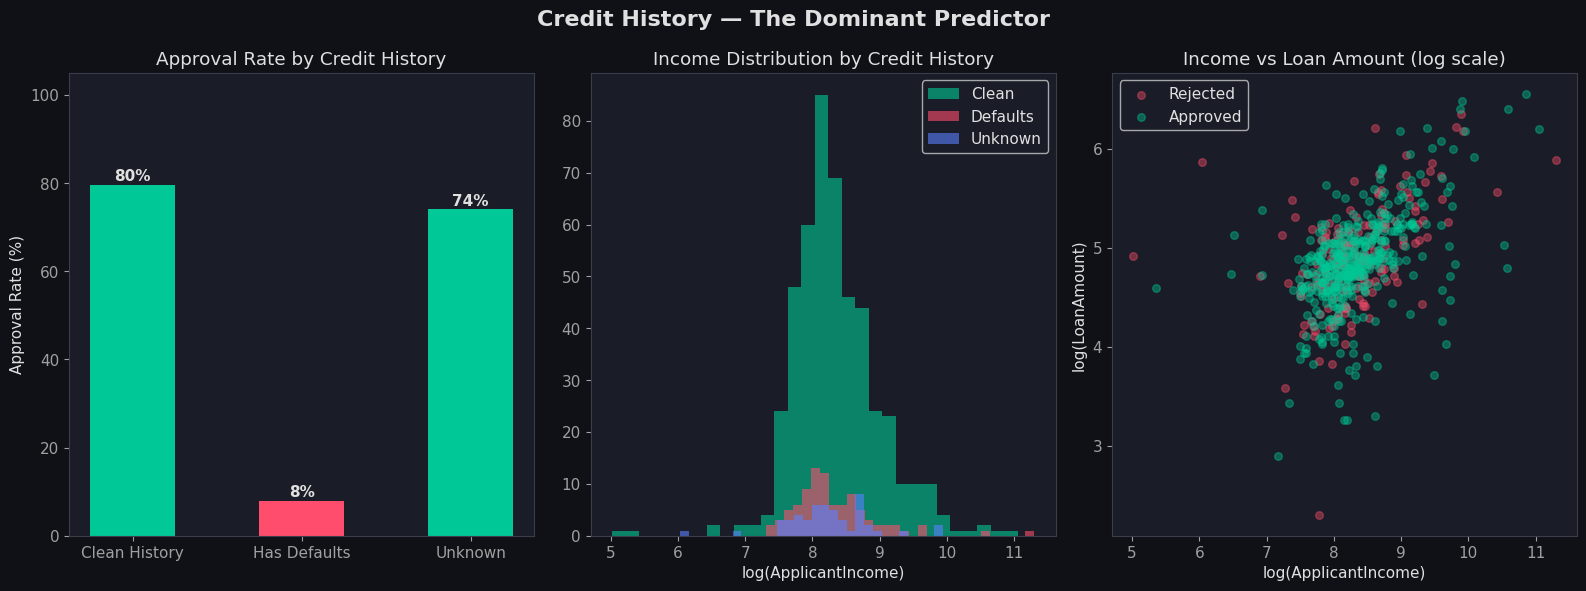

In [10]:
# ── CREDIT HISTORY vs APPROVAL: THE DOMINANT SIGNAL ─────────────────────────
# This chart tells the most important story in the dataset.
# It belongs on your README as the primary business insight visual.

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Credit History — The Dominant Predictor', fontsize=16, fontweight='bold')

# Map Credit_History back to readable labels for this chart
ch_labels = {1.0: 'Clean History', 0.0: 'Has Defaults', -1.0: 'Unknown'}
df['Credit_History_Label'] = df['Credit_History'].map(ch_labels)

# Chart 1: Approval rate by Credit_History
ch_approval = df.groupby('Credit_History_Label')['Loan_Status'].mean()
colors = [APPROVE_COLOR if v > 0.5 else REJECT_COLOR for v in ch_approval.values]
bars = axes[0].bar(ch_approval.index, ch_approval.values * 100,
                   color=colors, edgecolor='none', width=0.5)
for bar, val in zip(bars, ch_approval.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.0%}', ha='center', fontweight='bold')
axes[0].set_title('Approval Rate by Credit History')
axes[0].set_ylabel('Approval Rate (%)')
axes[0].set_ylim(0, 105)

# Chart 2: Income distribution for each credit history group
for ch_val, label, color in [(1.0, 'Clean', APPROVE_COLOR), 
                              (0.0, 'Defaults', REJECT_COLOR),
                              (-1.0, 'Unknown', NEUTRAL_COLOR)]:
    subset = df[df['Credit_History'] == ch_val]['ApplicantIncome'].dropna()
    axes[1].hist(np.log1p(subset), bins=30, alpha=0.6, color=color, 
                 label=label, edgecolor='none')
axes[1].set_title('Income Distribution by Credit History')
axes[1].set_xlabel('log(ApplicantIncome)')
axes[1].legend()

# Chart 3: LoanAmount vs ApplicantIncome scatter, colored by approval
approved = df[df['Loan_Status'] == 1]
rejected = df[df['Loan_Status'] == 0]
axes[2].scatter(np.log1p(rejected['ApplicantIncome']), 
                np.log1p(rejected['LoanAmount']),
                alpha=0.4, s=30, color=REJECT_COLOR, label='Rejected')
axes[2].scatter(np.log1p(approved['ApplicantIncome']), 
                np.log1p(approved['LoanAmount']),
                alpha=0.4, s=30, color=APPROVE_COLOR, label='Approved')
axes[2].set_title('Income vs Loan Amount (log scale)')
axes[2].set_xlabel('log(ApplicantIncome)')
axes[2].set_ylabel('log(LoanAmount)')
axes[2].legend()

plt.tight_layout()
plt.savefig('../data/processed/eda_05_credit_history_insight.png', dpi=150, bbox_inches='tight')
plt.show()